In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
from tqdm import tqdm

from joblib import Parallel, delayed

import pickle

import schwingerModel as sim

from schwingerModel.interpolator import MesonOp, mesonMultiplet, makeState

In [2]:
# with open('configs/50kSteps.pkl', 'rb') as f:
#     a1 = pickle.load(f)

In [3]:
# sim.distillation.generateDistillFile(modelObj=a1,filePath="./configs/50kSteps.hdf5",numVecs=5,autocorrSkip=50,DNums=(0,1,2),momks=(0,1,2))

In [4]:
def coshCorrel(nt, Energy, pivot,dimt):
    num = np.exp(-nt*Energy)+np.exp((nt-dimt)*Energy)
    denom = np.exp(-pivot*Energy)+np.exp((pivot-dimt)*Energy)
    return num/denom

In [5]:
def triplet(op):                       # the pi+-type member: connected-only, like the old path
    return mesonMultiplet(op, 1)[+1]

def singlet(op):                       
    return mesonMultiplet(op, 0)[0]

g5   = MesonOp("g5")
g5d2 = MesonOp("g5", DNum=2)
g5p, g5m = MesonOp("g5", 0, 1), MesonOp("g5", 0, -1)

pipi_00   = makeState([(g5,   1), (g5,   1)], I=2, I3=2)   # pi(g5)   pi(g5)
pipi_0d2  = makeState([(g5,   1), (g5d2, 1)], I=2, I3=2)   # pi(g5)   pi(g5 D2)
pipi_d2d2 = makeState([(g5d2, 1), (g5d2, 1)], I=2, I3=2)   # pi(g5D2) pi(g5D2)
pipi_k1 = makeState([(g5p,1), (g5m,1)], I=2, I3=2)      # auto parity-even, total k=0

In [6]:
path = "./configs/400kSteps.hdf5"
meta = sim.distillation.readDistillMeta(path)

basisPiPi = [pipi_00,pipi_0d2,pipi_d2d2,pipi_k1]
basisPi = [triplet(g5), triplet(g5d2)]

In [7]:
dataPiPi = sim.GEVP.measureEnsemble(path, (meta.configIndices)[::50], basisPiPi)
dataPi = sim.GEVP.measureEnsemble(path, (meta.configIndices)[::50], basisPi)

In [9]:
gevpTi = 2

out1 = sim.GEVP.bootstrapEnsemble(dataPiPi, reduce=sim.GEVP.makeGevpReduce(ti=gevpTi,shift=1))
out2 = sim.GEVP.bootstrapEnsemble(dataPi, reduce=sim.GEVP.makeGevpReduce(ti=gevpTi,shift=1))

In [ ]:
outM = sim.GEVP.bootstrapEnsemble(dataPiPi, reduce=sim.GEVP.massReduce(ti=gevpTi, shift=1,
                                  fitT=[2,10], withAmp=True))
pipiE, logApipi = outM[0][:, 0], outM[0][:, 1]
pipiErr = outM[1][:, :, 0].mean(axis=0)      # symmetrized mass errors per state

In [26]:
print(pipiE)

[1.2671051  1.77367952 1.70378634 2.10843737]


(1.0, 16.0)

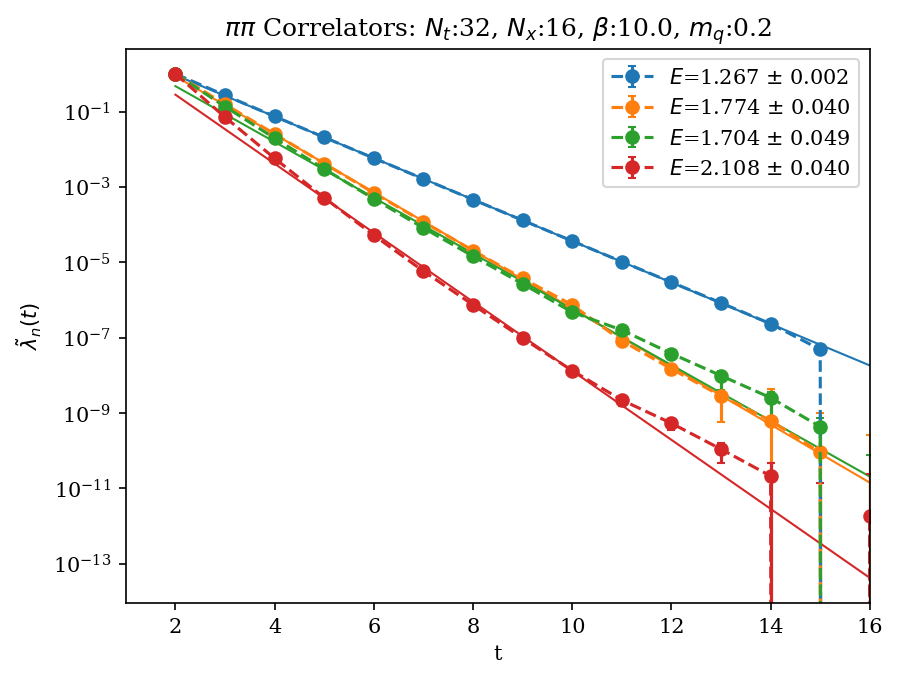

In [ ]:
central, err, cov = out1

ts = np.arange(gevpTi, gevpTi + central.shape[0])   # times of the shifted curves
tf = np.linspace(gevpTi, 16, 300)

plt.figure(dpi=150)
for e in range(central.shape[1]):
    line = plt.errorbar(ts, central[:, e], yerr=np.maximum(err[::-1, :, e], 0),
                        fmt='o--', capsize=2,
                        label=rf"$E$={pipiE[e]:.3f} $\pm$ {pipiErr[e]:.3f}")
    # fitted exponential from massReduce: exp(logA - E*(t - gevpTi)), the model
    # actually fit to these (shifted) curves — cosh is the wrong shape here
    plt.plot(tf, np.exp(logApipi[e] - pipiE[e]*(tf - gevpTi)),
             color=line[0].get_color(), lw=1)

plt.semilogy()
plt.xlabel("t"); plt.ylabel(r"$\tilde\lambda_n(t)$")
plt.legend()

plt.title(rf"$\pi\pi$ Correlators: $N_t$:{meta.dimt}, $N_x$:{meta.dimx}, $\beta$:{meta.beta}, $m_q$:{meta.fMass}")

plt.xlim([1,16])

In [ ]:
outMpi = sim.GEVP.bootstrapEnsemble(dataPi, reduce=sim.GEVP.massReduce(ti=gevpTi, shift=1,
                                  fitT=[2,10], withAmp=True))
piE, logApi = outMpi[0][:, 0], outMpi[0][:, 1]
piErr = outMpi[1][:, :, 0].mean(axis=0)      # symmetrized mass errors per state

In [29]:
print(piE)

[0.55169709 1.05786495]


(1.0, 16.0)

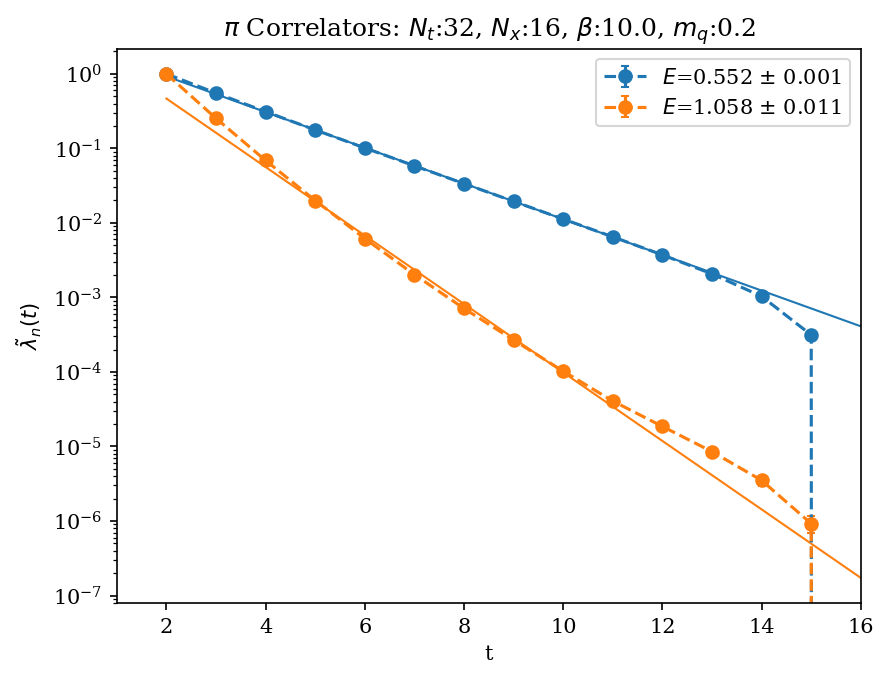

In [ ]:
central, err, cov = out2

ts = np.arange(gevpTi, gevpTi + central.shape[0])   # times of the shifted curves
tf = np.linspace(gevpTi, 16, 300)

plt.figure(dpi=150)
for e in range(central.shape[1]):
    line = plt.errorbar(ts, central[:, e], yerr=np.maximum(err[::-1, :, e], 0),
                        fmt='o--', capsize=2,
                        label=rf"$E$={piE[e]:.3f} $\pm$ {piErr[e]:.3f}")
    # fitted exponential from massReduce: exp(logA - E*(t - gevpTi)), the model
    # actually fit to these (shifted) curves — cosh is the wrong shape here
    plt.plot(tf, np.exp(logApi[e] - piE[e]*(tf - gevpTi)),
             color=line[0].get_color(), lw=1)

plt.semilogy()
plt.xlabel("t"); plt.ylabel(r"$\tilde\lambda_n(t)$")
plt.legend()

plt.title(rf"$\pi$ Correlators: $N_t$:{meta.dimt}, $N_x$:{meta.dimx}, $\beta$:{meta.beta}, $m_q$:{meta.fMass}")

plt.xlim([1,16])

In [31]:
basisEta = [singlet(g5),singlet(g5d2)]

dataEta = sim.GEVP.measureEnsemble(path, meta.configIndices[::25], basisEta)

In [32]:
outEta = sim.GEVP.bootstrapEnsemble(dataEta, reduce=sim.GEVP.makeGevpReduce(ti=gevpTi,shift=1))

In [48]:
outMeta = sim.GEVP.bootstrapEnsemble(dataEta, reduce=sim.GEVP.massReduce(ti=gevpTi, shift=1,
                                  fitT=[3,10], withAmp=True))
etaE, logAeta = outMeta[0][:, 0], outMeta[0][:, 1]
etaErr = outMeta[1][:, :, 0].mean(axis=0)      # symmetrized mass errors per state

/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/GEVP.py:137: UserWarning: bootstrapEnsemble: dropped 2936/10000 resamples with NaN reduce output
  warnings.warn(f"bootstrapEnsemble: dropped {(~valid).sum()}/{len(valid)} "


In [49]:
print(etaE)

[0.58048538 1.10454997]


(1.0, 16.0)

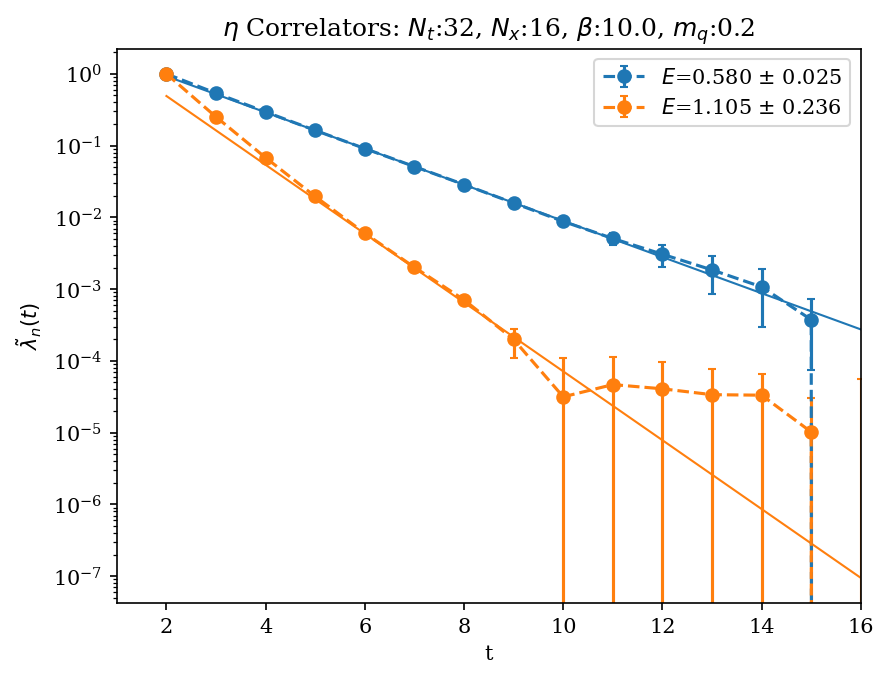

In [51]:
central, err, cov = outEta

ts = np.arange(gevpTi, gevpTi + central.shape[0])   # times of the shifted curves
tf = np.linspace(gevpTi, 16, 300)

plt.figure(dpi=150)
for e in range(central.shape[1]):
    line = plt.errorbar(ts, central[:, e], yerr=np.maximum(err[::-1, :, e], 0),
                        fmt='o--', capsize=2,
                        label=rf"$E$={etaE[e]:.3f} $\pm$ {etaErr[e]:.3f}")
    # fitted exponential from massReduce: exp(logA - E*(t - gevpTi)), the model
    # actually fit to these (shifted) curves — cosh is the wrong shape here
    plt.plot(tf, np.exp(logAeta[e] - etaE[e]*(tf - gevpTi)),
             color=line[0].get_color(), lw=1)

plt.semilogy()
plt.xlabel("t"); plt.ylabel(r"$\tilde\lambda_n(t)$")
plt.legend()

plt.title(rf"$\eta$ Correlators: $N_t$:{meta.dimt}, $N_x$:{meta.dimx}, $\beta$:{meta.beta}, $m_q$:{meta.fMass}")

plt.xlim([1,16])

In [46]:
etaeta_00   = makeState([(g5,   0), (g5,   0)], I=0, I3=0)   
etaeta_0d2  = makeState([(g5,   0), (g5d2, 0)], I=0, I3=0)   
etaeta_d2d2 = makeState([(g5d2, 0), (g5d2, 0)], I=0, I3=0)   
etaeta_k1 =   makeState([(g5p,  0), (g5m,  0)], I=0, I3=0)      # auto parity-even, total k=0

basisEtaEta = [etaeta_00,etaeta_0d2,etaeta_d2d2,etaeta_k1]

dataEtaEta = sim.GEVP.measureEnsemble(path, meta.configIndices[::20], basisEtaEta)

In [47]:
outEtaEta = sim.GEVP.bootstrapEnsemble(dataEtaEta, reduce=sim.GEVP.makeGevpReduce(ti=gevpTi,shift=1))

In [56]:
outMetaeta = sim.GEVP.bootstrapEnsemble(dataEtaEta, reduce=sim.GEVP.massReduce(ti=gevpTi, shift=1,
                                  fitT=[2,6], withAmp=True))
etaetaE, logAetaeta = outMetaeta[0][:, 0], outMetaeta[0][:, 1]
etaetaErr = outMetaeta[1][:, :, 0].mean(axis=0)      # symmetrized mass errors per state

/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/GEVP.py:137: UserWarning: bootstrapEnsemble: dropped 2120/10000 resamples with NaN reduce output
  warnings.warn(f"bootstrapEnsemble: dropped {(~valid).sum()}/{len(valid)} "


In [57]:
print(etaetaE)

[0.84528607 1.08749964 1.09528031 1.55321034]


(1.0, 16.0)

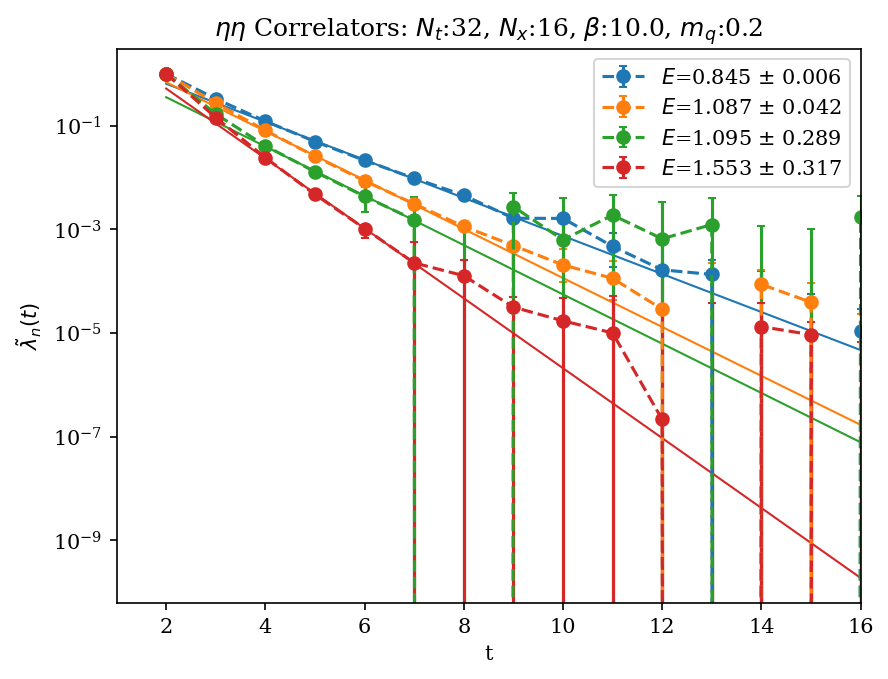

In [58]:
central, err, cov = outEtaEta

ts = np.arange(gevpTi, gevpTi + central.shape[0])   # times of the shifted curves
tf = np.linspace(gevpTi, 16, 300)

plt.figure(dpi=150)
for e in range(central.shape[1]):
    line = plt.errorbar(ts, central[:, e], yerr=np.maximum(err[::-1, :, e], 0),
                        fmt='o--', capsize=2,
                        label=rf"$E$={etaetaE[e]:.3f} $\pm$ {etaetaErr[e]:.3f}")
    # fitted exponential from massReduce: exp(logA - E*(t - gevpTi)), the model
    # actually fit to these (shifted) curves — cosh is the wrong shape here
    plt.plot(tf, np.exp(logAetaeta[e] - etaetaE[e]*(tf - gevpTi)),
             color=line[0].get_color(), lw=1)

plt.semilogy()
plt.xlabel("t"); plt.ylabel(r"$\tilde\lambda_n(t)$")
plt.legend()

plt.title(rf"$\eta\eta$ Correlators: $N_t$:{meta.dimt}, $N_x$:{meta.dimx}, $\beta$:{meta.beta}, $m_q$:{meta.fMass}")

plt.xlim([1,16])